# Ganglion cells size distributions

## Setup

### Import libraries:

In [13]:
import sys
sys.path.append('/home/jovyan/projects/cellcount/')
import os
print(os.getcwd())
os.chdir('/home/jovyan/projects/cellcount')
print(os.getcwd())
import pandas as pd
import numpy as np
#import scipy as sc
import matplotlib.pyplot as plt
# from matplotlib.ticker import MultipleLocator
# from matplotlib import gridspec
%matplotlib inline
# from skimage import io
# from skimage import measure
# from skimage import color
from PIL import Image
Image.MAX_IMAGE_PIXELS = None # avoid the "DOS decompression bomb warning/error" by unlimiting the size of the displayed image

from math import floor

# from shapely.geometry import Polygon, MultiPolygon, GeometryCollection
# from shapely.validation import explain_validity, make_valid

# from read_roi import read_roi_zip, read_roi_file
# from scipy.stats import kde

from collections import OrderedDict

from utils import *

/home/jovyan/projects/cellcount
/home/jovyan/projects/cellcount


### Choose parameters:

In [14]:
save_final_data = False

### Define paths:

In [15]:
path2kdrive = "/home/jovyan/kDrive"
path2mainfolder = os.path.join(path2kdrive, "cellcount/data/project_Aa_Hr_Fovea")
path2plots = os.path.join(path2mainfolder, "plots")
path2pickle = os.path.join(path2mainfolder, "pickled_data")
print(f"Plots will be saved in {path2plots}")

Plots will be saved in /home/jovyan/kDrive/cellcount/data/project_Aa_Hr_Fovea/plots


### Define environment variables:


| abbr | EN | FR | LA | 
| ------ | ------ | ------ | ----- |
| Hr | Barn Swallow | Hirondelle rustique | Hirundo rustica |
| An | Sparrowhawk | Epervier | Accipiter nisus |
| Aa | Common Swift | Martinet noir | Apus apus |
| Mc | Grey Wagtail | Bergeronnette des ruisseaux | Matocilla cinerea |
| Du | Northern House Martin | Hirondelle de fenêtre | Delichon urbicum |
| Ft | Common Kestrel | Faucon crécerelle | Falco tinnunculus |
| Mm04 | Black Kite | Milan noir | Milvus migrans |
| Cj | Japanese Quail | Caille | Coturnix japonica |


In [16]:
SPECIES_NAMES = {
    'Hr08': 'Barn\nSwallow',
    'Aa14': 'Common\nSwift',
    'Du25': 'House\nMartin',
    'Ft03': 'Common\nKestrel',
    'Mm04': 'Black\nKite',
    'Mc12': 'Grey\nWagtail',
    'An01': 'Eurasian\nSparrowhawk',
    'Cj22': 'Japanese\nQuail'
}

## data (GC sizes) for the following species and regions are already pickled:
SPECIES_AND_REGIONS_1 = [
    ('An01', 'NRtemporal'), ('Mc12', 'NRtemporal'), ('Mm04', 'NRtemporal'), ('Sa09', 'NRtemporal'),
    ('Aa14', 'FT'), ('Du26', 'FT'), ('Ft03', 'FT'), ('Hr08', 'FT'),
    ('Aa14', 'NR1-NR4'), ('Hr21', 'NR1-NR4'), None, None,
    ('Aa14', 'NRc'), ('Hr08', 'FC'), None, None
]

## data for these are computed from roisets:
SPECIES_AND_REGIONS_2 = [
    ('An01', 'FC'), ('An01', 'NR1-NR4'),
    ('Hr11', 'FC'), ('Hr11', 'FT'),
    ('Cj22', 'NRc'), ('Cj22', 'NRtemporal'), ('Cj22', 'NR1-NR4'),
    ('Du25', 'FC'),
    ('Ft03', 'FC'), ('Ft03', 'NR1-NR4'),
    ('Mc12', 'FC'), ('Mc12', 'NR1-NR4'),
    ('Mm04', 'FC')
]

REGIONS_DESCRIPTION = {
    'C': 'central area (C)',
    'T': 'temporal area (T)',
    'D-V': 'dorso-ventral axis (D-V)'
}

ROISETS = {
    'An01': {
        'FC': 'An01_Fc_36_1_2_RGC_RoiSet.zip',
        'NR1': 'An01_NR1_9_4_3_RoiSet.zip',
        'NR2': 'An01_NR2_5_3_4_RoiSet.zip',
        'NR3': 'An01_NR3_6_1_4_RoiSet.zip',
        'NR4': 'An01_NR4_4_1_4_RoiSet.zip'
    },
    'Hr11': {
        'FC': 'Hr11_Fc_18_2_2_RGC_RoiSet.zip',
        'FT': 'Hr11_Ft_25_3_1_RGC_40x_RoiSet.zip',
    },
    'Cj22': {
        'NRc': 'Cj22_NRc_6_3_2_RGC_RoiSet.zip',
        'NRtemporal': 'Cj22_NRt_3_4_2_RGC_RoiSet.zip',
        'NR1': 'Cj22_NR1_1_3_RoiSet.zip',
        'NR2': 'Cj22_NR2_3_3_RoiSet.zip',
        'NR3': 'Cj22_NR3_3_3_RoiSet.zip',
        'NR4': 'Cj22_NR4_2_3_RoiSet.zip'
    },
    'Du25': {
        'FC': 'Du25_Fc_29_4_1_RGC_RoiSet.zip'
    },
    'Ft03': {
        'FC': 'Ft03_Fc_28_3_2_GCL_RoiSet.zip',
        'NR1': 'Ft03_NR1_1_3_RoiSet.zip',
        'NR2': 'Ft03_NR2_5_3_RoiSet.zip',
        'NR3': 'Ft03_NR3_4_3_RoiSet.zip',
        'NR4': 'Ft03_NR4_3_2_RoiSet.zip'
    },
    'Mc12': {
        'FC': 'Mc12_FovC_17_2_2_RGC_RoiSet.zip',
        'NR1': 'Mc12_NR1_4_2_RoiSet.zip',
        'NR2': 'Mc12_NR2_4_2_RoiSet.zip',
        'NR3': 'Mc12_NR3_2_1_RoiSet.zip',
        'NR4': 'Mc12_NR4_3_2_RoiSet.zip'
    },
    'Mm04': {
        'FC': 'Mm04_Fc_54bis_2_2_RGC_RoiSet.zip'
    }
}

IMG_RATIO = { # microns/pixels
    'An01': {
        'FC': 0.156,
        'NR1-NR4': 0.156
    },
    'Hr11': {
        'FC': 0.156,
        'FT': 0.156,
    },
    'Cj22': {
        'NRc': 0.156,
        'NRtemporal': 0.156,
        'NR1-NR4': 0.312
    },
    'Du25': {
        'FC': 0.156
    },
    'Ft03': {
        'FC': 0.156,
        'NR1-NR4': 0.312
    },
    'Mc12': {
        'FC': 0.156,
        'NR1-NR4': 0.312
    },
    'Mm04': {
        'FC': 0.156
    }
}

FIGPARAMS = {
    'labelsize': 10,
    'fontsize': 12,
    'legendfontsize': 10,
    'legendtitlesize': 12,
}

SAMPLE_ORDERING = {
    'C': [
            ('Hr08', 'FC'), ('Aa14', 'NRc'), ('Du25', 'FC'), ('Ft03', 'FC'),
            ('Mm04', 'FC'), ('Mc12', 'FC'), ('An01', 'FC'), ('Cj22', 'NRc')
        ],
    'T': [
            ('Hr08', 'FT'), ('Aa14', 'FT'), ('Du26', 'FT'), ('Ft03', 'FT'), 
            ('Mm04', 'NRtemporal'), ('Mc12', 'NRtemporal'), ('An01', 'NRtemporal'), ('Cj22', 'NRtemporal')
        ],
    'D-V': [
            ('Hr21', 'NR1-NR4'), ('Aa14', 'NR1-NR4'), ('Du26', None), ('Ft03', 'NR1-NR4'), 
            ('Mm04', None), ('Mc12', 'NR1-NR4'), ('An01', 'NR1-NR4'), ('Cj22', 'NR1-NR4')
        ]
}

# Define colors for each violin
COLORS = ["#1E72FA", "#E01EFA", "#0145B3", "#1ED9FA", "#B87B2B", "#975408", "#E47900", "#37FF0F"]

## Import and prepare data

In [17]:
def import_GC_rois(species, region, load_data_from_pickle=False):

    if load_data_from_pickle:
        pickle_filename = f"GC_{species}_{region}.pickle"
        df_gc_areas = pd.read_pickle(os.path.join(path2pickle, pickle_filename))

        return df_gc_areas
    
    else:
        path2data = os.path.join(path2mainfolder, species + '_' + region)
        if region == 'NR1-NR4':
            rois = OrderedDict()
            for chunk in ['NR1', 'NR2', 'NR3', 'NR4']:
                path2roiset = os.path.join(path2data, ROISETS[species][chunk])
                #print(path2roiset)
                rois.update(read_roi_zip(path2roiset))
        else:
            path2roiset = os.path.join(path2data, ROISETS[species][region])
            #print(path2roiset)
            rois = read_roi_zip(path2roiset)
        polygon_list = []
        for r in rois:
            #print(r)
            if rois[r]['type'] in ['line', 'polyline']:
                pass
            else:
                coords = np.column_stack((rois[r]['x'], rois[r]['y']))
                #print(coords)
                polygon_list.append((r, contour2polygon(coords)))
                gc_areas = [polygon_list[i][1].area * IMG_RATIO[species][region]**2 for i in range(len(polygon_list))]
                df_gc_areas = pd.DataFrame({'gc_area': gc_areas})
        
        return df_gc_areas

## test:
# df_test = import_GC_rois('Aa14', 'FT', True)
# df_test = import_GC_rois('Hr11', 'FC', False)
# df_test

In [18]:
GC_sizes_dict = {}
for sr in SPECIES_AND_REGIONS_1:
    if sr is not None:
        species, region = sr
        GC_sizes_dict[species + '_' + region] = import_GC_rois(species, region, load_data_from_pickle=True)
for sr in SPECIES_AND_REGIONS_2:
    if sr is not None:
        species, region = sr
        GC_sizes_dict[species + '_' + region] = import_GC_rois(species, region, load_data_from_pickle=False)

In [19]:
GC_areas = {}
sample_names = []
for s in GC_sizes_dict.keys():
    species, region = s.split('_')
    print(f"species: {species} ; region: {region}")
    if region not in GC_areas.keys():
        GC_areas[region] = {}
    
    GC_areas[region][species] = GC_sizes_dict[s]['gc_area'].to_list()

species: An01 ; region: NRtemporal
species: Mc12 ; region: NRtemporal
species: Mm04 ; region: NRtemporal
species: Sa09 ; region: NRtemporal
species: Aa14 ; region: FT
species: Du26 ; region: FT
species: Ft03 ; region: FT
species: Hr08 ; region: FT
species: Aa14 ; region: NR1-NR4
species: Hr21 ; region: NR1-NR4
species: Aa14 ; region: NRc
species: Hr08 ; region: FC
species: An01 ; region: FC
species: An01 ; region: NR1-NR4
species: Hr11 ; region: FC
species: Hr11 ; region: FT
species: Cj22 ; region: NRc
species: Cj22 ; region: NRtemporal
species: Cj22 ; region: NR1-NR4
species: Du25 ; region: FC
species: Ft03 ; region: FC
species: Ft03 ; region: NR1-NR4
species: Mc12 ; region: FC
species: Mc12 ; region: NR1-NR4
species: Mm04 ; region: FC


## Plot data

### Violin plots:

In [22]:
def set_axis_style(ax, labels, region):
    ax.xaxis.set_tick_params(direction='out')
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_xlim(0, 9)
    #ax.set_xlabel('frames')
    ax.set_ylabel('cell area / $\mu$m$^2$ ')
    if region == 'C':
        #ymax = 200
        ymax = 500
    elif region == 'T':
        ymax = 500
    elif region == 'D-V':
        #ymax = 300
        ymax = 500
    ax.set_ylim(ymin=0, ymax=ymax)

def adjacent_values(vals, q1, q3):
    upper_adjacent_value = q3 + (q3 - q1) * 1.5
    upper_adjacent_value = np.clip(upper_adjacent_value, q3, vals[-1])
    lower_adjacent_value = q1 - (q3 - q1) * 1.5
    lower_adjacent_value = np.clip(lower_adjacent_value, vals[0], q1)
    return lower_adjacent_value, upper_adjacent_value

('Hr08', 'FC')
('Aa14', 'NRc')
('Du25', 'FC')
('Ft03', 'FC')
('Mm04', 'FC')
('Mc12', 'FC')
('An01', 'FC')
('Cj22', 'NRc')
('Hr08', 'FT')
('Aa14', 'FT')
('Du26', 'FT')
('Ft03', 'FT')
('Mm04', 'NRtemporal')
('Mc12', 'NRtemporal')
('An01', 'NRtemporal')
('Cj22', 'NRtemporal')
('Hr21', 'NR1-NR4')
('Aa14', 'NR1-NR4')
('Du26', None)
('Ft03', 'NR1-NR4')
('Mm04', None)
('Mc12', 'NR1-NR4')
('An01', 'NR1-NR4')
('Cj22', 'NR1-NR4')


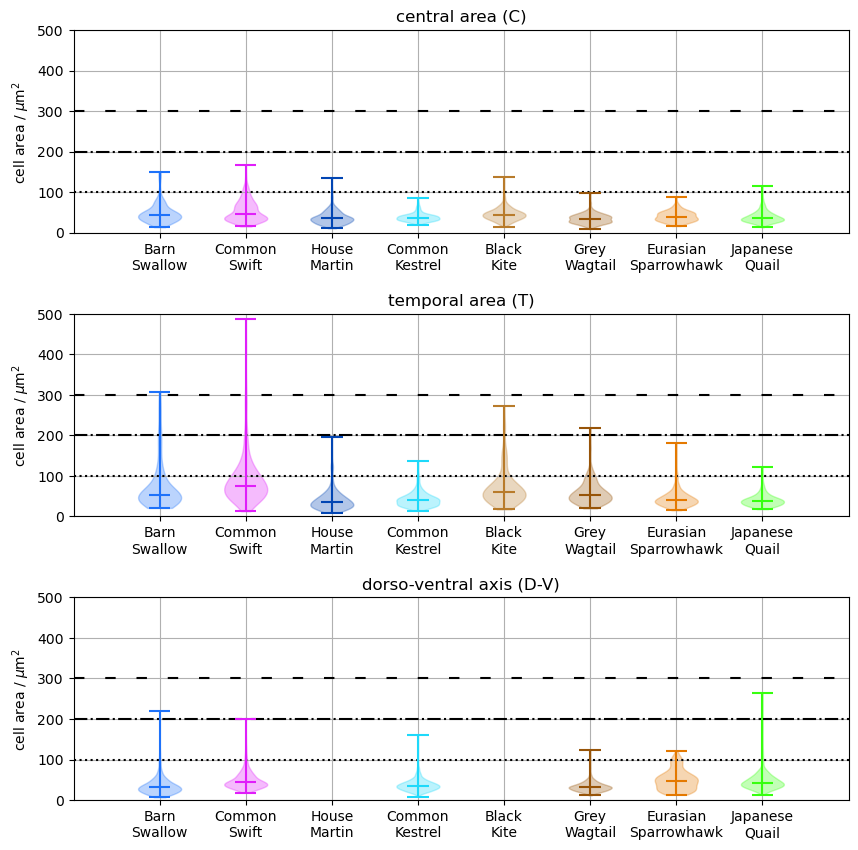

In [23]:
spec = gridspec.GridSpec(ncols=1, nrows=3, hspace=0.4, wspace=0.2)
fig = plt.figure(figsize=(10,10))

counter = 0
for region in ['C', 'T', 'D-V']:
    data_ordered = []
    positions = []
    for i, p in enumerate(SAMPLE_ORDERING[region]):
        print(p)
        if p[1] is not None:
            data_ordered.append(GC_areas[p[1]][p[0]])
            positions.append(i + 1) 

    sample_names = [p[0] for p in SAMPLE_ORDERING['C']]
    ax = fig.add_subplot(spec[counter])
    ax.hlines(100, 0, 9, color='black', linestyle='dotted')
    ax.hlines(200, 0, 9, color='black', linestyle='dashdot')
    ax.hlines(300, 0, 9, color='black', linestyle=(0, (5,10)))

    vp = plt.violinplot(data_ordered, positions=positions, showmeans=False, showmedians=True, showextrema=True)

    # apply different colors to each violin:
    for i, pc in enumerate(vp['bodies']):
        pc.set_facecolor(COLORS[positions[i]-1])
        pc.set_edgecolor(COLORS[positions[i]-1])
        pc.set_alpha(0.3)
        
    if region == 'D-V':
        bar_colors = [col for i, col in enumerate(COLORS) if i not in [2,4]]
    else:
        bar_colors = COLORS
    
    # Also color the median lines, quartiles, etc.
    vp['cmedians'].set_colors(bar_colors)
    vp['cmaxes'].set_colors(bar_colors)
    vp['cmins'].set_colors(bar_colors)
    vp['cbars'].set_colors(bar_colors)

    ax.grid()
    set_axis_style(ax, [SPECIES_NAMES[s] for s in sample_names], region)
    ax.set_title(REGIONS_DESCRIPTION[region])

    counter += 1

if save_final_data:
    fig.savefig(os.path.join(path2plots, 'GC_sizes_violinplots.png'), facecolor='white')

### Histograms

In [24]:
def plot_GC_size_distributions(species_and_regions, load_data_from_pickle=False, mosaic=False, save_plot=False, path2savemosaic=None):
    if mosaic:
        spec = gridspec.GridSpec(ncols=4, nrows=4, hspace=0.4, wspace=0.2)
        fig = plt.figure(figsize=(20,20))
        text_position = (0.25, 0.95)
        text_fontsize = 10
    else:
        spec = gridspec.GridSpec(ncols=1, nrows=1, hspace=0.1, wspace=0.1)
        text_position = (0.45, 0.95)
        text_fontsize = 12

    counter = 0
    for sr in species_and_regions:
        if sr is not None:
            species, region = sr
            print(f"processing species {species} and region {region}")
            df_gc_areas = import_GC_rois(species, region, load_data_from_pickle)                  
            area_thr = 100 # fix threshold
            areas = list(df_gc_areas.gc_area)
            percent_gt_thr = round(len([True for i in areas if i > area_thr]) / len(areas) * 100) 
            print(f"Largest GC is : {np.max(areas)} $\mu$m$^2$")
            bin_width = 10

        if not mosaic:
            if sr is not None:
                fig = plt.figure(figsize=(7,5))
                ax = fig.add_subplot(spec[0])
        else:
            ax = fig.add_subplot(spec[counter])
            counter += 1

        if sr is not None:
            output_hist = ax.hist(areas, np.arange(0, floor(np.max(areas)) + 2 * bin_width, bin_width), log=False, density=False, edgecolor='black', zorder=2)
            ax.set_ylabel('counts', fontsize=FIGPARAMS['fontsize'])
            ax.set_xlabel(r'GC area  / $\mu$m$^2$', fontsize=FIGPARAMS['fontsize'])
            textstr = '\n'.join((
            f'total number of GC: {len(areas)}',
            f'median area of a GC: {np.median(areas): .0f} $\mu$m$^2$',
            f'proportion of GC $\geq {area_thr} \ \mu$m$^2$: {percent_gt_thr:.0f} %'
            ))
            ax.text(text_position[0], text_position[1], textstr, transform=ax.transAxes, fontsize=text_fontsize, verticalalignment='top', horizontalalignment='left')
            ax.set_title(f"{species} - {region}")
            ax.set_xlim(xmin=0, xmax=500)

            if region == 'NR1-NR4':
                y_max = 600
            # elif region in ['NRc', 'NRtemporal']:
            #     y_max = 100
            else:
                y_max = 140
            
            ax.set_ylim(ymin=0, ymax=y_max)
            # change the fontsize of tick labels:
            ax.tick_params(axis='x', labelsize=FIGPARAMS['labelsize'])
            ax.tick_params(axis='y', labelsize=FIGPARAMS['labelsize'])
            ax.grid()
        
        else:
            if mosaic:
                ax.axis('off')
                ax.set_frame_on(False)
            else:
                pass

        if not mosaic:
            if save_plot:
                fig.savefig(os.path.join(path2plots, f"ganglion_cells_area_distribution_{species}_{region}.png"), facecolor='white')

    if mosaic:
        fig.suptitle(f"Ganglion cells sizes distribution accross all species and regions", fontsize=18)
        if save_plot:
            fig.savefig(path2savemosaic, facecolor='white')

processing species An01 and region FC
Largest GC is : 88.972416 $\mu$m$^2$
processing species An01 and region NR1-NR4
Largest GC is : 120.390192 $\mu$m$^2$
processing species Hr11 and region FC
Largest GC is : 159.266952 $\mu$m$^2$
processing species Hr11 and region FT
Largest GC is : 457.57764 $\mu$m$^2$
processing species Cj22 and region NRc
Largest GC is : 114.951096 $\mu$m$^2$
processing species Cj22 and region NRtemporal
Largest GC is : 122.616936 $\mu$m$^2$
processing species Cj22 and region NR1-NR4
Largest GC is : 264.53232 $\mu$m$^2$
processing species Du25 and region FC
Largest GC is : 134.930952 $\mu$m$^2$
processing species Ft03 and region FC
Largest GC is : 84.591936 $\mu$m$^2$
processing species Ft03 and region NR1-NR4
Largest GC is : 160.65543355791092 $\mu$m$^2$
processing species Mc12 and region FC
Largest GC is : 99.059688 $\mu$m$^2$
processing species Mc12 and region NR1-NR4
Largest GC is : 124.405632 $\mu$m$^2$
processing species Mm04 and region FC
Largest GC is : 13

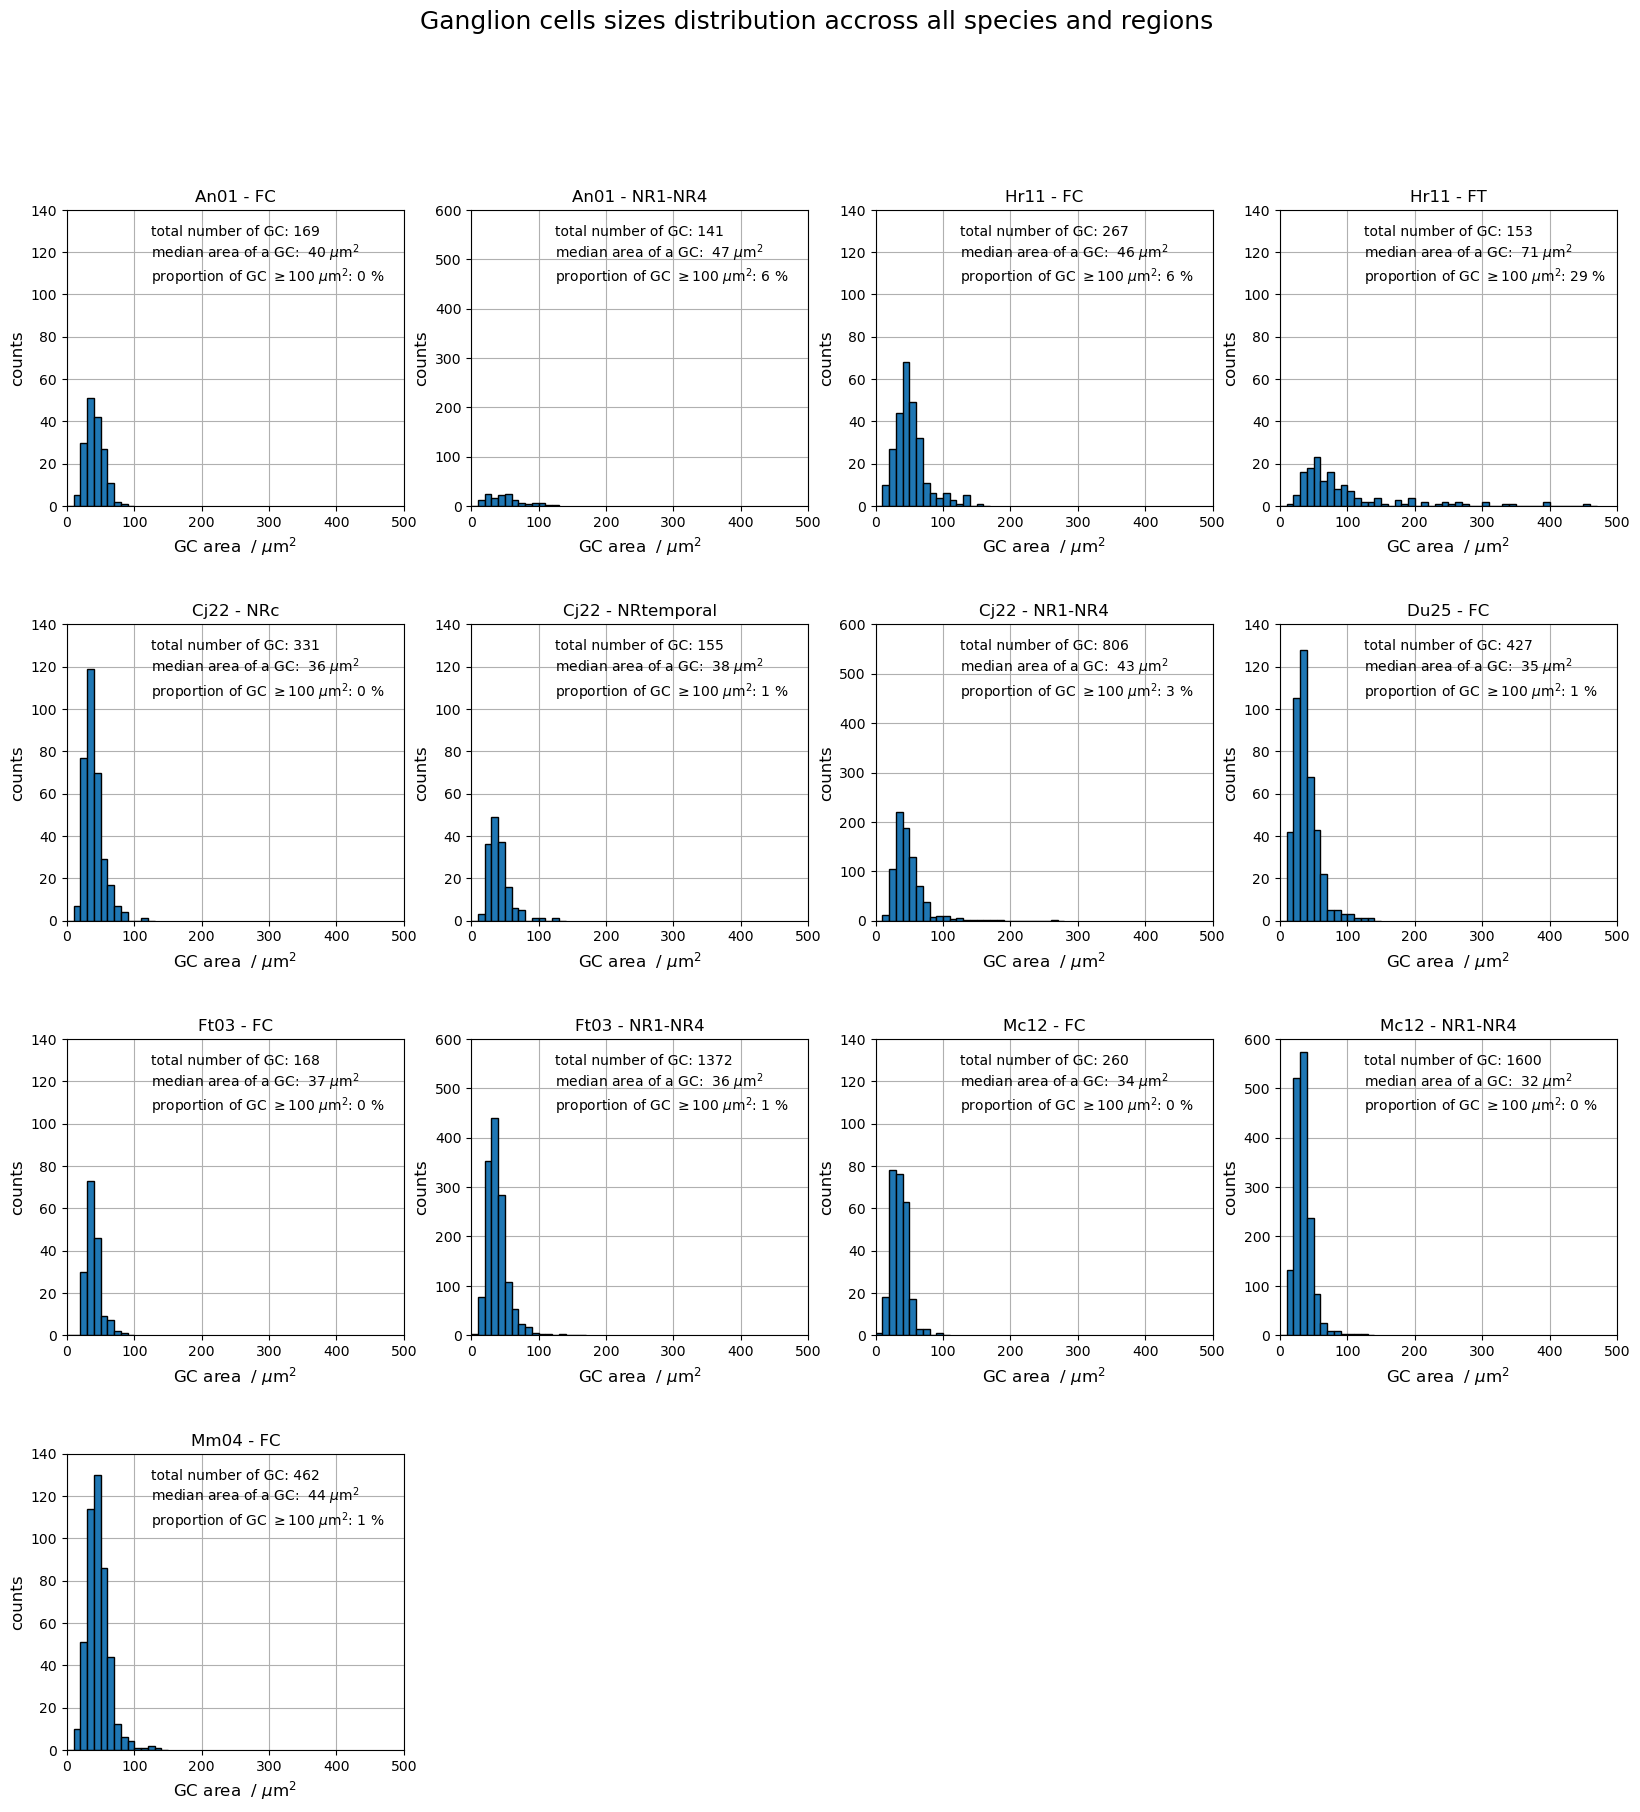

In [25]:
plot_GC_size_distributions(
    species_and_regions=SPECIES_AND_REGIONS_2,
    load_data_from_pickle=False,
    mosaic=True,
    save_plot=save_final_data,
    path2savemosaic=os.path.join(path2plots, f"ganglion_cells_area_distribution_comparison_all_2.png") # ignored if save_plot or mosaic is False
)